# 02 — SAM 3 multi-class segmentation per frame

**Objetivo:** pipeline deployable que dado un frame, devuelve máscaras para TODAS las clases definidas y las overlays en un solo panel con colores distintos.

**Diferencia con 01:** 01 mostraba 1 prompt por subplot. **02 muestra todas las clases en el mismo subplot** (como saldría en producción).

**Flujo:**
1. Carga SAM 3 (`bfloat16`, CPU)
2. Define `CLASSES = {nombre: color_rgb}` (3 clases: pelota, robot, cancha)
3. Prueba sobre 2 formatos de video:
   - **Landscape** (`17Abril/Cámaras/` — cámara externa 1920×1080)
   - **Portrait** (`17Abril/*.MOV` — Meta Glasses ~1456×1936)
4. Extrae 4 frames evenly spaced por video
5. Por frame: corre SAM 3 una vez por clase, combina resultados
6. Muestra grid: filas=frames, columnas=videos

**Tiempo estimado:** ~3.5 min (24 inferencias × ~9 s).

**Pipeline reusable:** la función `detect_classes_in_frame()` al final es directamente trasladable a producción.

## 1. Imports

In [1]:
import sys, time
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import decord
import cv2
from transformers import AutoProcessor, AutoModel

WORKSPACE = Path('/workspace')
REPO = WORKSPACE / 'FutBotMX-UAQTeam'
SAM3_PATH = REPO / 'assets' / 'sam3'
DATA = REPO / 'data' / 'raw'

print('Python:', sys.version.split()[0], '| torch:', torch.__version__)

Python: 3.11.13 | torch: 2.11.0+cu128


## 2. Cargar SAM 3

In [2]:
t0 = time.time()
processor = AutoProcessor.from_pretrained(str(SAM3_PATH))
model = AutoModel.from_pretrained(
    str(SAM3_PATH),
    dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
).to('cuda')
model.eval()
print(f'Carga: {time.time()-t0:.1f}s | params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M')

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Carga: 24.2s | params: 859.9M


## 3. Definir clases + colores

Cada clase es un prompt de texto + un color RGB pa' visualizar. Pa' agregar/cambiar clases solo edita este dict.

In [3]:
# {prompt_texto: color_RGB_0-255}
CLASSES: Dict[str, Tuple[int, int, int]] = {
    'orange ball':  (255, 100,   0),  # naranja
    'robot':        ( 60, 130, 255),  # azul cielo
    'green playing surface with lines':  ( 50, 220,  70),  # verde brillante
}

print(f'{len(CLASSES)} clases definidas:')
for cls, col in CLASSES.items():
    print(f'  "{cls:15s}"  →  RGB{col}')

3 clases definidas:
  "orange ball    "  →  RGB(255, 100, 0)
  "robot          "  →  RGB(60, 130, 255)
  "green playing surface with lines"  →  RGB(50, 220, 70)


## 4. Pipeline deployable

Las dos funciones críticas. **Estas dos son directamente reutilizables en producción.**

`segment_with_text` → 1 prompt, devuelve N máscaras (multi-instancia).  
`detect_classes_in_frame` → corre todas las clases sobre 1 frame, devuelve dict por clase.

In [4]:
def mask_from_logits(logits, W0, H0):
    """Logits del modelo (~288x288) -> upscale BILINEAR a full-res -> threshold.
    Borde suave sub-pixel (no escalones NEAREST). NMS/hole-fill/sprinkle lo hace la lib `kernels` en origen."""
    lo = logits.astype(np.float32)
    if lo.shape != (H0, W0):
        lo = cv2.resize(lo, (W0, H0), interpolation=cv2.INTER_LINEAR)
    return lo > 0.0

@dataclass
class Detection:
    obj_id: int
    mask: np.ndarray
    score: float

@torch.no_grad()
def segment_with_text(image: Image.Image, text: str) -> List[Detection]:
    """Detecciones. Upscale bilinear de logits + post-proc kernels."""
    session = processor.init_video_session(
        video=[image],
        inference_device='cuda',
        dtype=torch.bfloat16,
    )
    session = processor.add_text_prompt(session, text=text)
    out = model(inference_session=session, frame_idx=0)

    W0, H0 = image.size
    dets = []
    for obj_id in out.object_ids:
        m = out.obj_id_to_mask[obj_id].detach().cpu().float().numpy()
        if m.ndim == 4: m = m[0, 0]
        elif m.ndim == 3: m = m[0]
        dets.append(Detection(
            obj_id=int(obj_id),
            mask=mask_from_logits(m, W0, H0),
            score=float(out.obj_id_to_score.get(obj_id, 0.0)),
        ))
    return dets

def detect_classes_in_frame(
    image: Image.Image,
    classes: Dict[str, Tuple[int, int, int]],
) -> Dict[str, List[Detection]]:
    return {cls: segment_with_text(image, cls) for cls in classes}

print('Funciones: segment_with_text + detect_classes_in_frame + mask_from_logits (bilinear)')


Funciones: segment_with_text + detect_classes_in_frame + mask_from_logits (bilinear)


## 5. Multi-class overlay

Combina máscaras de todas las clases en un solo overlay coloreado. En overlap (raro), última clase pintada gana — pero usamos alpha blending así que generalmente se ve mezcla.

In [5]:
def multi_class_overlay(
    image: Image.Image,
    detections_by_class: Dict[str, List[Detection]],
    class_colors: Dict[str, Tuple[int, int, int]],
    alpha: float = 0.55,
) -> np.ndarray:
    """Devuelve image RGB (float 0-1) con todas las clases overlaid."""
    img = np.array(image).astype(np.float32) / 255.0
    H, W, _ = img.shape
    overlay = img.copy()

    for cls, dets in detections_by_class.items():
        color = np.array(class_colors[cls], dtype=np.float32) / 255.0
        for det in dets:
            mask = det.mask
            if mask.shape != (H, W):
                mask = np.array(Image.fromarray(mask.astype(np.uint8)*255).resize((W, H), Image.NEAREST)) > 0
            overlay[mask] = (1 - alpha) * overlay[mask] + alpha * color
    return overlay

def make_legend_patches(class_colors: Dict[str, Tuple[int, int, int]]):
    return [
        mpatches.Patch(color=np.array(c)/255.0, label=cls)
        for cls, c in class_colors.items()
    ]

## 6. Elegir videos de prueba (2 formatos)

Para validar generalización probamos un video de cada cámara:
- **Landscape:** `17Abril/Cámaras/` — cámara externa 1920×1080
- **Portrait:** `17Abril/*.mov` raíz — Meta Glasses ~1456×1936

In [6]:
video_landscape = sorted((DATA / '17Abril' / 'Cámaras').glob('*.MOV'))[0]
video_portrait  = sorted([f for f in (DATA / '17Abril').glob('*.mov') if f.is_file()])[0]

VIDEOS = [
    ('Cámara externa (landscape)', video_landscape),
    ('Meta Glasses (portrait)',    video_portrait),
]

for label, p in VIDEOS:
    vr = decord.VideoReader(str(p))
    h, w = vr[0].shape[:2]
    print(f'  {label:30s}  {p.name}  →  {w}x{h} @ {vr.get_avg_fps():.0f}fps  ({len(vr)}f)')

  Cámara externa (landscape)      IMG_9779.MOV  →  1920x1080 @ 30fps  (1044f)


  Meta Glasses (portrait)         video-297_singular_display.mov  →  1456x1936 @ 30fps  (2099f)


## 7. Extraer 4 frames por video

In [7]:
N_FRAMES = 4
frames_per_video = {}  # label -> [(frame_idx, PIL.Image), ...]

for label, p in VIDEOS:
    vr = decord.VideoReader(str(p))
    total = len(vr)
    idxs = list(np.linspace(0, total - 1, N_FRAMES, dtype=int))
    arr = vr.get_batch(idxs).asnumpy()
    imgs = [(int(i), Image.fromarray(a)) for i, a in zip(idxs, arr)]
    frames_per_video[label] = imgs
    print(f'{label:30s}  indices: {idxs}')

Cámara externa (landscape)      indices: [np.int64(0), np.int64(347), np.int64(695), np.int64(1043)]


Meta Glasses (portrait)         indices: [np.int64(0), np.int64(699), np.int64(1398), np.int64(2098)]


## 8. Inferencia: por cada video × cada frame × cada clase

Total: 2 × 4 × 3 = 24 inferencias × ~9 s = ~3.5 min.

In [8]:
results = {}  # (video_label, frame_position_idx) -> {class: [Detection]}
t_start = time.time()

for label, frames in frames_per_video.items():
    print(f'\n=== {label} ===')
    for fi, (fidx, img) in enumerate(frames):
        t0 = time.time()
        det_dict = detect_classes_in_frame(img, CLASSES)
        dt = time.time() - t0
        summary = ', '.join(f'{cls}={len(d)}' for cls, d in det_dict.items())
        print(f'  frame={fidx:4d}  [{dt:4.1f}s]  {summary}')
        results[(label, fi)] = det_dict

print(f'\nTotal {time.time()-t_start:.1f}s ({len(VIDEOS)} videos × {N_FRAMES} frames × {len(CLASSES)} clases)')


=== Cámara externa (landscape) ===


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

  frame=   0  [ 5.3s]  orange ball=1, robot=3, green playing surface with lines=2


  frame= 347  [ 0.3s]  orange ball=1, robot=2, green playing surface with lines=2


  frame= 695  [ 0.3s]  orange ball=1, robot=2, green playing surface with lines=2


  frame=1043  [ 0.3s]  orange ball=1, robot=1, green playing surface with lines=1

=== Meta Glasses (portrait) ===


  frame=   0  [ 0.3s]  orange ball=1, robot=2, green playing surface with lines=1


  frame= 699  [ 0.3s]  orange ball=1, robot=4, green playing surface with lines=1


  frame=1398  [ 0.3s]  orange ball=0, robot=1, green playing surface with lines=1


  frame=2098  [ 0.3s]  orange ball=1, robot=0, green playing surface with lines=1

Total 7.4s (2 videos × 4 frames × 3 clases)


## 9. Visualización — grid (filas=frames, columnas=videos)

Cada celda muestra el frame original con TODAS las clases overlaid simultáneamente con sus colores.

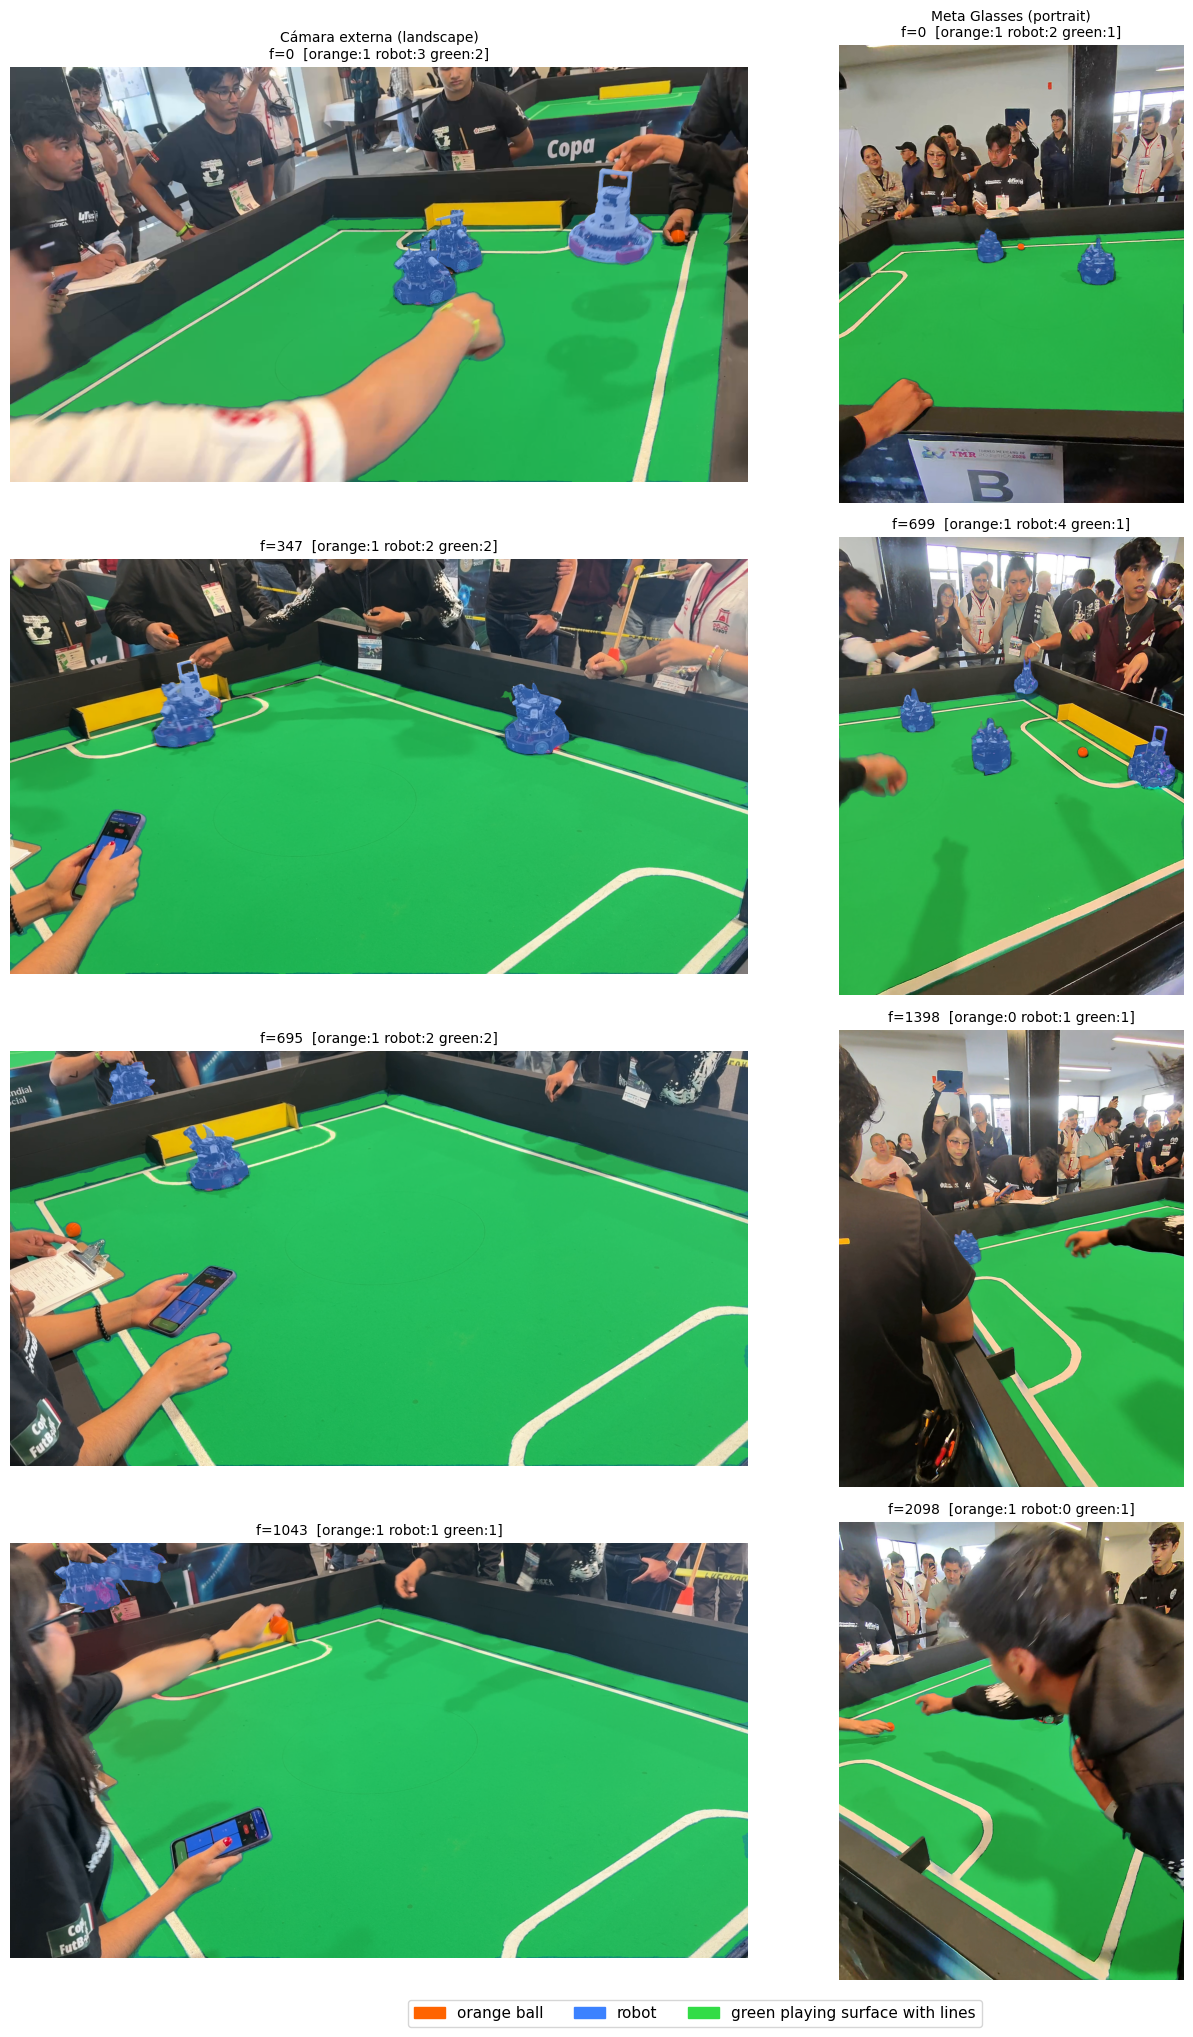

In [9]:
n_videos = len(VIDEOS)
n_frames = N_FRAMES

fig, axes = plt.subplots(n_frames, n_videos, figsize=(7*n_videos, 5*n_frames))
if n_videos == 1:
    axes = axes.reshape(-1, 1)

for col, (label, frames) in enumerate(frames_per_video.items()):
    for row, (fidx, img) in enumerate(frames):
        det_dict = results[(label, row)]
        ax = axes[row, col]
        overlay = multi_class_overlay(img, det_dict, CLASSES)
        ax.imshow(overlay)
        counts = ' '.join(f'{cls.split()[0]}:{len(d)}' for cls, d in det_dict.items())
        if row == 0:
            ax.set_title(f'{label}\nf={fidx}  [{counts}]', fontsize=10)
        else:
            ax.set_title(f'f={fidx}  [{counts}]', fontsize=10)
        ax.axis('off')

# Legend global
fig.legend(
    handles=make_legend_patches(CLASSES),
    loc='lower center',
    ncol=len(CLASSES),
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02),
)
plt.tight_layout()
plt.show()

## 10. Tabla resumen — detecciones por video × clase

In [10]:
print(f'{"Video":35s}  {"Clase":15s}  {"frames con det":>14s}  {"avg inst":>8s}  {"avg score":>9s}')
print('-' * 95)
for label in [v[0] for v in VIDEOS]:
    for cls in CLASSES:
        per_frame_counts = []
        per_frame_scores = []
        for fi in range(N_FRAMES):
            dets = results[(label, fi)][cls]
            per_frame_counts.append(len(dets))
            per_frame_scores.extend([d.score for d in dets])
        frames_with = sum(1 for c in per_frame_counts if c > 0)
        avg_inst = np.mean(per_frame_counts)
        avg_score = np.mean(per_frame_scores) if per_frame_scores else 0.0
        print(f'{label:35s}  {cls:15s}  {frames_with:>5d}/{N_FRAMES}        {avg_inst:>8.2f}  {avg_score:>9.3f}')

Video                                Clase            frames con det  avg inst  avg score
-----------------------------------------------------------------------------------------------
Cámara externa (landscape)           orange ball          4/4            1.00      0.752
Cámara externa (landscape)           robot                4/4            2.00      0.865
Cámara externa (landscape)           green playing surface with lines      4/4            1.75      0.827
Meta Glasses (portrait)              orange ball          3/4            0.75      0.831
Meta Glasses (portrait)              robot                3/4            1.75      0.864
Meta Glasses (portrait)              green playing surface with lines      4/4            1.00      0.962


## 11. Hand-off a producción

**API mínima reusable** (estas dos funciones + `CLASSES`):

```python
result = detect_classes_in_frame(pil_image, CLASSES)
# result = {'orange ball': [Detection, ...], 'robot': [...], 'green floor': [...]}
```

Cada `Detection` trae:
- `mask`: `np.ndarray` bool (H, W) — alineada al tamaño original del frame
- `score`: confianza del decoder (0-1)
- `obj_id`: id interno (útil pa' tracking en notebook 04)

**Modificar clases:** edita el dict `CLASSES` arriba (sección 3). Cada nueva clase = 1 forward más por frame (~9 s en CPU, ~0.2 s en GPU 5090).

**Próximos notebooks:**
- `03_sam3_box_prompt.ipynb` — bbox manual con coords hardcoded (más preciso para objetos chicos/ambiguos).
- `04_sam3_video_tracking.ipynb` — propagar máscara a lo largo del video (no re-inferir cada frame).
- **Fase 1:** LoRA fine-tuning pa' clases específicas no resueltas por texto open-vocab (e.g. ally vs enemy si añadimos marcadores).